<a href="https://colab.research.google.com/github/Dev-Joyson/CNN-based-GAN-face-detection/blob/main/Test11_FFT_Bug_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from collections import Counter
import os
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = 256
COMMON_NATIVE_SIZE = 512
BATCH_SIZE = 144

In [ ]:
REAL_DIR = "/content/drive/MyDrive/Research/Dataset/Real"
FAKE_DIR = "/content/drive/MyDrive/Research/Dataset/Fake"

def load_paths(real_dir, fake_dir, limit_per_class=8000):
    real_images = sorted(glob(os.path.join(real_dir, '*')))[:limit_per_class]
    fake_images = sorted(glob(os.path.join(fake_dir, '*')))[:limit_per_class]

    paths = real_images + fake_images
    labels = [0]*len(real_images) + [1]*len(fake_images)

    return train_test_split(paths, labels, test_size=0.3, stratify=labels, random_state=SEED)

train_paths, test_paths, train_labels, test_labels = load_paths(REAL_DIR, FAKE_DIR)


val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, stratify=test_labels, random_state=SEED)

print("Train:", Counter(train_labels))
print("Val:  ", Counter(val_labels))
print("Test: ", Counter(test_labels))

Train: Counter({1: 5600, 0: 5600})
Val:   Counter({1: 1200, 0: 1200})
Test:  Counter({1: 1200, 0: 1200})


# Augmentation

In [ ]:
def random_jpeg(image):
    quality = tf.random.uniform([], 60, 100, dtype=tf.int32)
    image_uint8 = tf.cast(image * 255.0, tf.uint8)
    image_uint8 = tf.image.adjust_jpeg_quality(image_uint8, quality)
    image = tf.cast(image_uint8, tf.float32) / 255.0
    return image


def random_blur(image):
    return tf.cond(
        tf.random.uniform([]) < 0.3,
        lambda: tf.nn.avg_pool2d(image[None],
                                 ksize=3,
                                 strides=1,
                                 padding="SAME")[0],
        lambda: image
    )

def random_crop_resize(image):
    crop_frac = tf.random.uniform([], 0.95, 1.0)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    crop_h = tf.cast(crop_frac * tf.cast(h, tf.float32), tf.int32)
    crop_w = tf.cast(crop_frac * tf.cast(w, tf.float32), tf.int32)

    image = tf.image.random_crop(image, size=[crop_h, crop_w, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE],
                             method=tf.image.ResizeMethod.BICUBIC)
    return image

In [ ]:
def _feathered_ellipse(size=IMG_SIZE, rx_frac=0.38, ry_frac=0.48, feather=0.05):
    yy, xx = tf.meshgrid(tf.range(size, dtype=tf.float32),
                         tf.range(size, dtype=tf.float32), indexing='ij')
    c = (size - 1) / 2.0
    r = tf.sqrt(((xx - c)/(rx_frac*size))**2 + ((yy - c)/(ry_frac*size))**2)
    m = tf.clip_by_value((1.0 - r)/feather + 0.5, 0.0, 1.0)   # 1 inside → 0 outside, soft edge
    return m[..., tf.newaxis]                                   # (size, size, 1)

FACE_MASK = _feathered_ellipse()

(256, 256, 1)


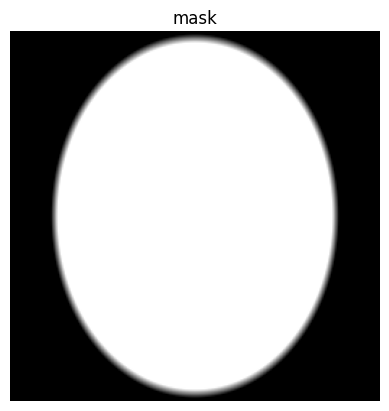

In [ ]:
print(FACE_MASK.shape)                    # (256, 256, 1)
plt.imshow(FACE_MASK[...,0], cmap='gray'); plt.title("mask"); plt.axis("off"); plt.show()

In [ ]:
def preprocess_image(path, label, training=True):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    # Normalize native resolution (fix resolution bias)
    image = tf.image.resize(image, [COMMON_NATIVE_SIZE, COMMON_NATIVE_SIZE],
                             method=tf.image.ResizeMethod.BICUBIC)

    # Resize to model input
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE],
                             method=tf.image.ResizeMethod.BICUBIC)

    image = tf.cast(image, tf.float32) / 255.0

    if training:
        image = random_crop_resize(image)
        image = random_blur(image)
        image = tf.cond(tf.random.uniform([]) < 0.3,
                        lambda: random_jpeg(image),
                        lambda: image)

    image = image * FACE_MASK      # ← NEW: both classes, train + val + test
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def build_dataset(paths, labels, batch_size=96, shuffle=True, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: preprocess_image(x, y, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(train_paths, train_labels, BATCH_SIZE,
                         shuffle=True, training=True)

val_ds   = build_dataset(val_paths, val_labels, BATCH_SIZE,
                         shuffle=False, training=False)

test_ds  = build_dataset(test_paths, test_labels, BATCH_SIZE,
                         shuffle=False, training=False)

In [ ]:
for imgs, lbls in train_ds.take(1):
    plt.figure(figsize=(12,3))
    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(imgs[i].numpy())
        plt.title("REAL" if lbls[i].numpy()==0 else "FAKE")
        plt.axis("off")
    plt.show()
    break

KeyboardInterrupt: 

In [ ]:
def fft_layer(x):
    # x: (batch, H, W, 3), float in [0,1]

    # 1) Collapse color so the inner two axes become (H, W) — the real image grid
    g = tf.image.rgb_to_grayscale(x)          # (B, H, W, 1)
    g = tf.squeeze(g, axis=-1)                # (B, H, W)   ← last two are now row, column

    # 2) 2D FFT over (H, W), now the correct axes
    fft = tf.signal.fft2d(tf.cast(g, tf.complex64))   # (B, H, W) complex
    mag = tf.abs(fft)                                 # magnitude spectrum

    # 3) Center the zero-frequency (nicer layout for the conv; optional but standard)
    mag = tf.signal.fftshift(mag, axes=[1, 2])

    # 4) Log-compress the huge dynamic range (once, not twice)
    mag = tf.math.log1p(mag)                          # (B, H, W)

    # 5) Per-sample normalize to [0,1] so scale is consistent across images
    mn = tf.reduce_min(mag, axis=[1, 2], keepdims=True)
    mx = tf.reduce_max(mag, axis=[1, 2], keepdims=True)
    mag = (mag - mn) / (mx - mn + 1e-6)

    return mag[..., tf.newaxis]                        # (B, H, W, 1)

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    return x

In [ ]:
def build_simple_cnn_with_fft():
    input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Enhanced Spatial Branch
    x = conv_block(input_img, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)


    # FFT Branch
    f = layers.Lambda(fft_layer)(input_img)
    f = layers.Conv2D(16, 3, activation='relu', padding='same')(f)
    f = layers.MaxPooling2D()(f)

    f = layers.Conv2D(32, 3, activation='relu', padding='same')(f)
    f = layers.GlobalAveragePooling2D()(f)

    # Fusion
    combined = layers.Concatenate()([x, f])
    combined = layers.Dense(128, activation='relu')(combined)
    combined = layers.Dropout(0.4)(combined)
    output = layers.Dense(1, activation='sigmoid')(combined)

    model = models.Model(inputs=input_img, outputs=output)
    return model

model = build_simple_cnn_with_fft()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │        160 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    590,080 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 256) │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d_5[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ max_pooling2d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_6[0][0]  

 Total params: 1,020,417 (3.89 MB)

 Trainable params: 1,020,417 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class LivePlot(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.acc, self.val_acc = [], []
        self.loss, self.val_loss = [], []

    def on_epoch_end(self, epoch, logs=None):
        self.acc.append(logs['accuracy'])
        self.val_acc.append(logs['val_accuracy'])
        self.loss.append(logs['loss'])
        self.val_loss.append(logs['val_loss'])
        self.plot()

    def plot(self):
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(self.acc, label='Train Acc', color='blue')
        plt.plot(self.val_acc, label='Val Acc', color='red')
        plt.title('Accuracy')
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(self.loss, label='Train Loss', color='blue')
        plt.plot(self.val_loss, label='Val Loss', color='red')
        plt.title('Loss')
        plt.legend()
        plt.show()

callbacks = [
    LivePlot(),
    tf.keras.callbacks.ModelCheckpoint(
        "simple_cnn_with_fft_and_spatial.keras",
        save_best_only=True,
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True
    )
]

history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks)

Epoch 1/50
46/78 ━━━━━━━━━━━━━━━━━━━━ 36:20 68s/step - accuracy: 0.5336 - auc: 0.5616 - loss: 0.6817

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


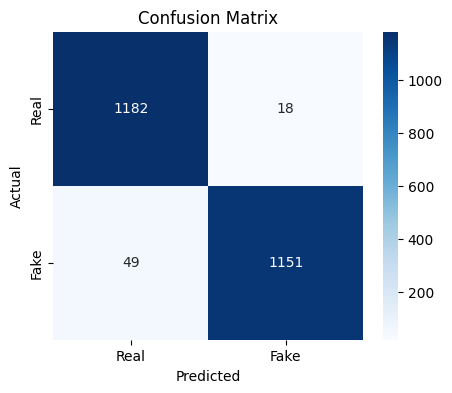

              precision    recall  f1-score   support

        Real       0.96      0.98      0.97      1200
        Fake       0.98      0.96      0.97      1200

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
weighted avg       0.97      0.97      0.97      2400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


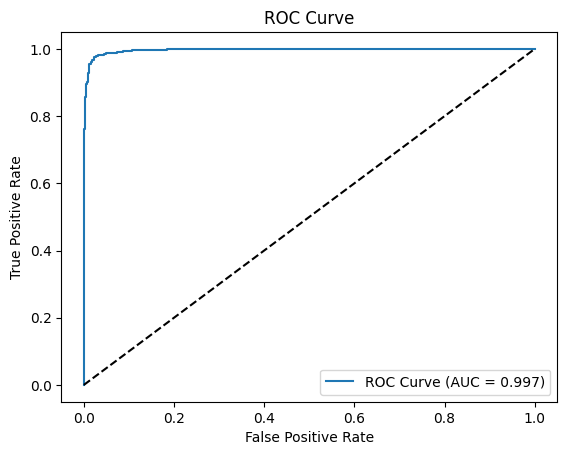

In [ ]:
from sklearn.metrics import roc_curve, auc

y_scores = []

for images, _ in test_ds:
    preds = model.predict(images)
    y_scores.extend(preds.flatten())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
import time

# Warm-up
dummy = tf.random.uniform((1, IMG_SIZE, IMG_SIZE, 3))
model.predict(dummy)

# Timing
times = []
for i in range(50):
    img = tf.expand_dims(train_ds.take(1).as_numpy_iterator().__next__()[0][0], axis=0)
    start = time.time()
    model.predict(img)
    times.append(time.time() - start)

print(f"Average inference time per image: {np.mean(times)*1000:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

### Test a single image

In [ ]:
model_path = "/content/drive/MyDrive/Research/Trained_models/test_10_augmented_cnn_with_fft.keras"
loaded_model = tf.keras.models.load_model(model_path, custom_objects={'fft_layer': fft_layer})

print("Model loaded successfully")

Model loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

Saving download (1).jfif to download (1).jfif
Uploaded image: download (1).jfif


In [ ]:
def preprocess_single_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)  # (1, H, W, 3)
    return img

In [ ]:
img = preprocess_single_image(image_path)

prediction = loaded_model.predict(img)[0][0]

label = "FAKE" if prediction > 0.5 else "REAL"
confidence = prediction if prediction > 0.5 else (1 - prediction)

print(f"Prediction: {label}")
print(f"Confidence: {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: REAL
Confidence: 96.65%


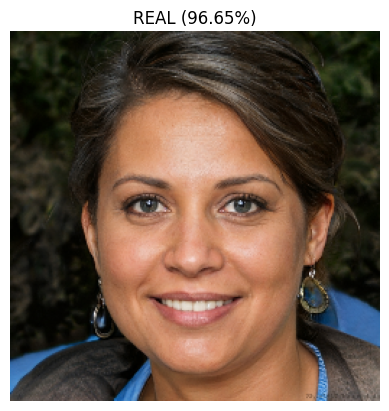

In [ ]:
plt.imshow(tf.squeeze(img))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)


Saving 9.jpeg to 9 (1).jpeg
Uploaded: 9 (1).jpeg


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 256

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [ ]:
def mask_background_fixed_ellipse(img_path, img_size=256):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError("Image not found")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    # Create fixed ellipse mask
    mask = np.zeros((h, w), dtype=np.uint8)

    center_x = w // 2
    center_y = h // 2

    # These values work well for FFHQ / StyleGAN aligned faces
    axis_x = int(w * 0.38)   # width
    axis_y = int(h * 0.48)   # height

    cv2.ellipse(
        mask,
        (center_x, center_y),
        (axis_x, axis_y),
        angle=0,
        startAngle=0,
        endAngle=360,
        color=255,
        thickness=-1
    )

    masked = np.zeros_like(img_rgb)
    masked[mask == 255] = img_rgb[mask == 255]

    masked = cv2.resize(masked, (img_size, img_size))
    masked = masked.astype(np.float32) / 255.0

    return masked


In [ ]:
import cv2
import numpy as np

def mask_background_fixed_ellipse_blur(img_path, img_size=256):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError("Image not found")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    # Ellipse mask (fixed)
    mask = np.zeros((h, w), dtype=np.uint8)
    center_x, center_y = w // 2, h // 2
    axis_x, axis_y = int(w * 0.38), int(h * 0.48)

    cv2.ellipse(mask, (center_x, center_y), (axis_x, axis_y),
                0, 0, 360, 255, -1)

    # Blur full image
    blurred = cv2.GaussianBlur(img_rgb, (41, 41), 0)

    # Combine: inside ellipse = original, outside = blurred
    out = blurred.copy()
    out[mask == 255] = img_rgb[mask == 255]

    out = cv2.resize(out, (img_size, img_size))
    out = out.astype(np.float32) / 255.0

    return out


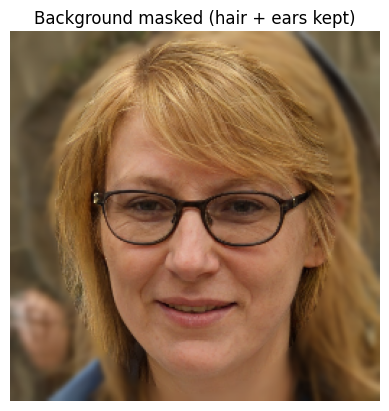

In [ ]:
bg_masked_img = mask_background_fixed_ellipse_blur(img_path)

plt.imshow(bg_masked_img)
plt.title("Background masked (hair + ears kept)")
plt.axis("off")
plt.show()

In [ ]:
img_input = np.expand_dims(bg_masked_img, axis=0)

pred = loaded_model.predict(img_input)[0][0]
label = "FAKE" if pred > 0.5 else "REAL"
confidence = pred if pred > 0.5 else (1 - pred)

print(f"Prediction: {label}")
print(f"Confidence: {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: FAKE
Confidence: 97.72%


In [ ]:
import cv2

In [ ]:
for layer in loaded_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

conv2d_7
conv2d_8
conv2d_9
conv2d_10
conv2d_12
conv2d_11
conv2d_13


In [ ]:
def compute_gradcam(model, img_tensor, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


def overlay_gradcam(img_tensor, heatmap, alpha=0.4):
    img = img_tensor[0].numpy()
    img = (img * 255).astype(np.uint8)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay

In [ ]:
LAST_CONV_LAYER = "conv2d_13"

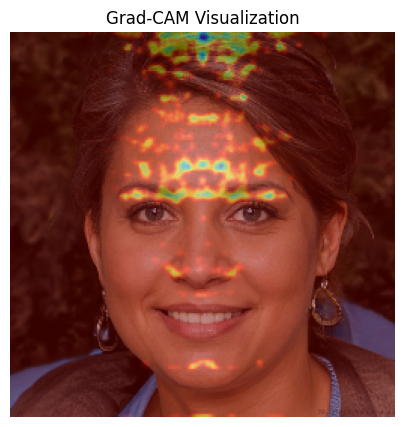

In [ ]:
heatmap = compute_gradcam(
    loaded_model,
    img,
    LAST_CONV_LAYER
)

gradcam_img = overlay_gradcam(img, heatmap)

plt.figure(figsize=(5,5))
plt.imshow(gradcam_img)
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()